# Understanding Linear Regression: From Equation to Prediction

In this notebook, we will implement **Simple Linear Regression** using Python and scikit-learn.

Simple Linear Regression predicts a numerical value using one input feature. For this project, we will work with a salary prediction dataset and build a model that learns the relationship between experience and salary.

Before training any Machine Learning model, we should first understand the dataset. That means looking at the rows, columns, data types, missing values, duplicates, and the relationship between the feature and the target.

## 1. Import Required Libraries

We start by importing the libraries needed for loading data, working with arrays, creating graphs, training the model, evaluating predictions, and saving the trained model.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

## 2. Load the Dataset

The dataset should be downloaded from Kaggle and placed at `data/Salary_dataset.csv`.

If the file is missing, the next cell will show a clear message instead of silently creating fake data. We want this project to use the real dataset only.

In [2]:
# Path.cwd() gives the current notebook folder.
# .parent moves one level up to the main project folder.
dataset_path = Path.cwd().parent / "data" / "Salary_dataset.csv"

# Read the CSV file and store it in a pandas DataFrame.
df = pd.read_csv(dataset_path)

# The Kaggle CSV includes an extra index column named "Unnamed: 0".
# It is only a row number, not useful information for prediction, so we remove it.
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

Now we inspect the dataset before making any modeling decisions. This is where we confirm what the file actually contains.

In [3]:
# Show the first five rows to get a quick look at the dataset.
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [4]:
# Show the number of rows and columns in the dataset.
df.shape

(30, 2)

In [5]:
# Show column names, non-null counts, and data types.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [6]:
# Show all column names in the dataset.
df.columns

Index(['YearsExperience', 'Salary'], dtype='str')

In [7]:
# Check the data type of each column.
df.dtypes

YearsExperience    float64
Salary             float64
dtype: object

In [8]:
# Show summary statistics for the numerical columns.
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


## 3. Why We Study the Dataset First

Before training a Machine Learning model, we should not directly jump to `model.fit()`. We need to understand what the dataset contains, what each column means, whether the data has missing values, whether the column types are correct, and which column should be used as the feature and which should be used as the target.

Studying the dataset first helps us avoid mistakes like choosing the wrong target column, training on irrelevant columns, missing hidden null values, or misunderstanding what the model is actually learning.

## 4. Understand the Dataset

The previous cells showed the actual columns present in the CSV. After removing the extra saved index column, the dataset contains two meaningful columns.

For this salary prediction dataset, `YearsExperience` is the input feature and `Salary` is the target value we want to predict.

In [9]:
print("Columns found in the dataset:")
for column in df.columns:
    print(f"- {column}")

Columns found in the dataset:
- YearsExperience
- Salary


In [10]:
# After inspecting df.columns, we select the one input column and one target column.
feature_column = "YearsExperience"
target_column = "Salary"

print(f"Input feature column selected: {feature_column}")
print(f"Target column selected: {target_column}")

Input feature column selected: YearsExperience
Target column selected: Salary


The next cell describes the two columns we will use for Simple Linear Regression.

In [11]:
print(f"{feature_column}: selected as the input feature. It represents years of work experience.")
print(f"{target_column}: selected as the target. This is the salary value the model will learn to predict.")

YearsExperience: selected as the input feature. It represents years of work experience.
Salary: selected as the target. This is the salary value the model will learn to predict.


## 5. Check Data Types

Data types matter because Linear Regression needs numerical input. If a number is stored as text, scikit-learn cannot use it directly for training.

We will check the data types and then make sure the selected feature and target columns are numeric.

In [12]:
# Check data types again before converting selected columns.
df.dtypes

YearsExperience    float64
Salary             float64
dtype: object

In [13]:
# Convert the selected columns to numbers so scikit-learn can use them.
df[feature_column] = pd.to_numeric(df[feature_column], errors="coerce")
df[target_column] = pd.to_numeric(df[target_column], errors="coerce")

df[[feature_column, target_column]].dtypes

YearsExperience    float64
Salary             float64
dtype: object

## 6. Check for Missing Values

Missing values can affect model training because the model needs complete numerical values for the feature and target. If a row is missing the input or the answer, the model cannot learn from that row correctly.

We first count missing values, then remove rows only if the selected feature or target is missing.

In [14]:
# Count missing values in each column.
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [15]:
# Keep only rows where both the feature and target values are present.
rows_before_missing_check = len(df)
df = df.dropna(subset=[feature_column, target_column]).copy()
rows_removed = rows_before_missing_check - len(df)

if rows_removed > 0:
    print(f"Removed {rows_removed} row(s) with missing feature or target values.")
else:
    print("No missing values were found in the selected feature and target columns. The dataset is clean in this part.")

No missing values were found in the selected feature and target columns. The dataset is clean in this part.


## 7. Check for Duplicate Rows

Duplicate rows can make the model give extra importance to repeated examples. For a small beginner dataset, it is a good habit to check for duplicates and remove them if they exist.

In [16]:
# Count how many rows are exact duplicates.
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [17]:
# Remove duplicate rows only if the dataset contains any.
if duplicate_count > 0:
    df = df.drop_duplicates().copy()
    print(f"Removed {duplicate_count} duplicate row(s).")
else:
    print("No duplicate rows were found.")

No duplicate rows were found.


## 8. Basic Descriptive Statistics

`df.describe()` gives a quick numerical summary of the dataset.

- `count` tells us how many values are present.
- `mean` tells us the average value.
- `std` tells us how spread out the values are.
- `min` and `max` show the smallest and largest values.

This helps us understand the range of the data before training the model.

In [18]:
# Review count, mean, standard deviation, minimum, and maximum values.
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.413333,76004.000000
std,2.837888,27414.429785
min,1.200000,37732.000000
25%,3.300000,56721.750000
50%,4.800000,65238.000000
75%,7.800000,100545.750000
max,10.600000,122392.000000


## 9. Visualize the Dataset

Graphs help us see patterns that are harder to notice in tables. For Simple Linear Regression, a scatter plot is especially useful because it shows whether the feature and target seem to move together in a roughly straight-line pattern.

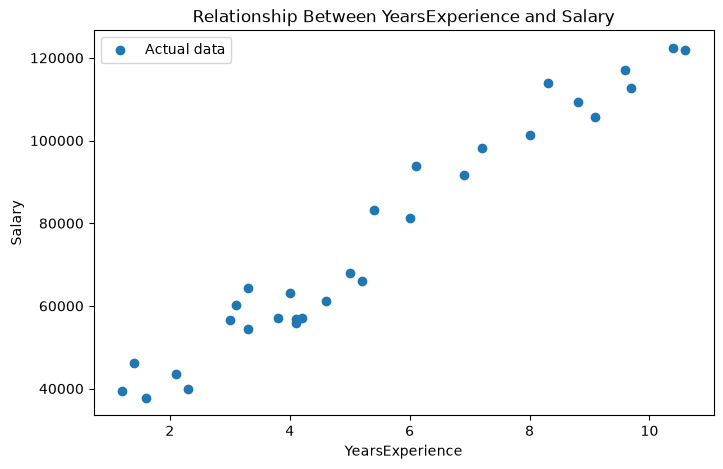

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(df[feature_column], df[target_column], label="Actual data")
plt.title(f"Relationship Between {feature_column} and {target_column}")
plt.xlabel(feature_column)
plt.ylabel(target_column)
plt.legend()
plt.show()

The next histogram shows how the input feature values are distributed. This helps us see whether the feature values are spread across a useful range.

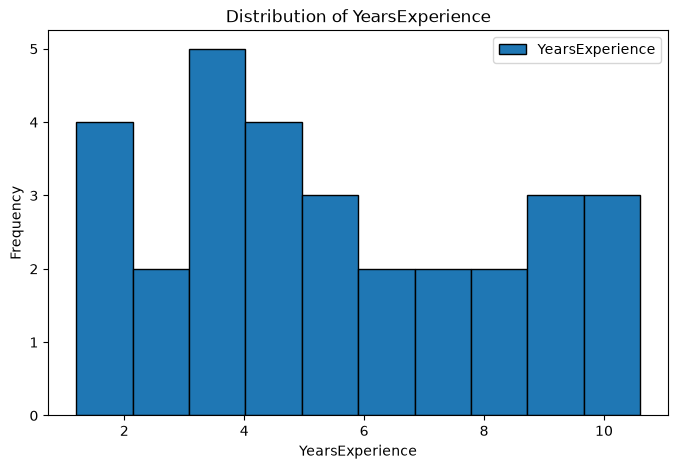

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df[feature_column], bins=10, edgecolor="black", label=feature_column)
plt.title(f"Distribution of {feature_column}")
plt.xlabel(feature_column)
plt.ylabel("Frequency")
plt.legend()
plt.show()

This histogram shows how the target values are distributed. It gives us a quick idea of the salary range in the dataset.

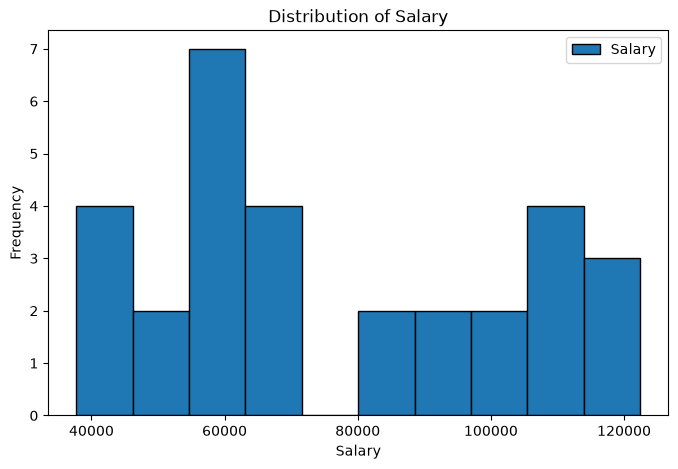

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(df[target_column], bins=10, edgecolor="black", label=target_column)
plt.title(f"Distribution of {target_column}")
plt.xlabel(target_column)
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 10. Select Feature and Target

Now we create `X` and `y` for the model.

`X` contains the input feature. We keep it as a 2D DataFrame using double brackets because scikit-learn expects feature data to be two-dimensional, even when there is only one feature.

`y` contains the target values we want the model to predict.

In [22]:
# X must be a 2D DataFrame because scikit-learn expects a table of features.
X = df[[feature_column]]
y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 1)
y shape: (30,)


## 11. Train-Test Split

We split the dataset into training and testing sets.

The training set is used to teach the model. The testing set is kept aside so we can check how well the model performs on data it did not see during training.

In [23]:
# Use 80% of the data for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training feature shape: (24, 1)
Testing feature shape: (6, 1)


## 12. Train the Linear Regression Model

Now we create a `LinearRegression` model and train it using `fit()`.

During `fit()`, scikit-learn calculates the best coefficient and intercept for the straight line that fits the training data.

In [24]:
# Create the model object, then train it on the training data.
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.438e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


## 13. Display Coefficient and Intercept

The coefficient tells us how much the target value changes when the input feature increases by one unit.

The intercept is the predicted target value when the input feature is zero.

Here, we interpret those values using the actual feature and target column names selected from the dataset.

In [25]:
coefficient = model.coef_[0]
intercept = model.intercept_

print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)
print()
print(f"Interpretation: For every 1 unit increase in {feature_column}, the predicted {target_column} changes by about {coefficient:.2f}.")
print(f"When {feature_column} is 0, the model predicts {target_column} to be about {intercept:.2f}.")

Coefficient: [9423.81532303]
Intercept: 24380.20147947369

Interpretation: For every 1 unit increase in YearsExperience, the predicted Salary changes by about 9423.82.
When YearsExperience is 0, the model predicts Salary to be about 24380.20.


## 14. Make Predictions

Now we use the trained model to predict values for the test set. Then we compare the actual values with the predicted values.

In [26]:
# Predict salaries for the test feature values.
y_pred = model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
})
comparison_df["Difference"] = comparison_df["Actual"] - comparison_df["Predicted"]

comparison_df

,Actual,Predicted,Difference
0,112636.0,115791.210113,-3155.210113
1,67939.0,71499.278095,-3560.278095
2,113813.0,102597.868661,11215.131339
3,83089.0,75268.804224,7820.195776
4,64446.0,55478.792045,8967.207955
5,57190.0,60190.699707,-3000.699707


## 15. Evaluate the Model

Model evaluation tells us how close the predictions are to the actual values. Since this is a salary prediction problem, the errors are measuring how far the predicted salary is from the actual salary.

- **MAE** means Mean Absolute Error. It tells us the average size of the prediction mistake, ignoring whether the model predicted too high or too low. For example, if MAE is `5000`, the model's salary predictions are off by about `5000` on average.
- **MSE** means Mean Squared Error. It squares each error before averaging them. Because of this, large mistakes become much more important than small mistakes. MSE is useful for comparing models, but it is harder to read directly because the unit is squared salary.
- **RMSE** means Root Mean Squared Error. It is the square root of MSE, so it comes back to the same unit as the target column. For this dataset, RMSE can be read as an approximate salary error, but it still gives extra weight to large mistakes.
- **R2 Score** tells us how well the model explains the variation in salary. A score close to `1` means the line fits the data well. A score close to `0` means the model is not much better than simply predicting the average salary. A negative score means the model is performing worse than that simple average-based guess.

In [27]:
# Calculate common regression evaluation metrics.
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 6286.45
Mean Squared Error (MSE): 49830096.86
Root Mean Squared Error (RMSE): 7059.04
R2 Score: 0.9024


## 16. Visualize the Regression Line

A Simple Linear Regression model learns a straight line. The scatter plot shows the actual data points, and the line shows the model's learned relationship.

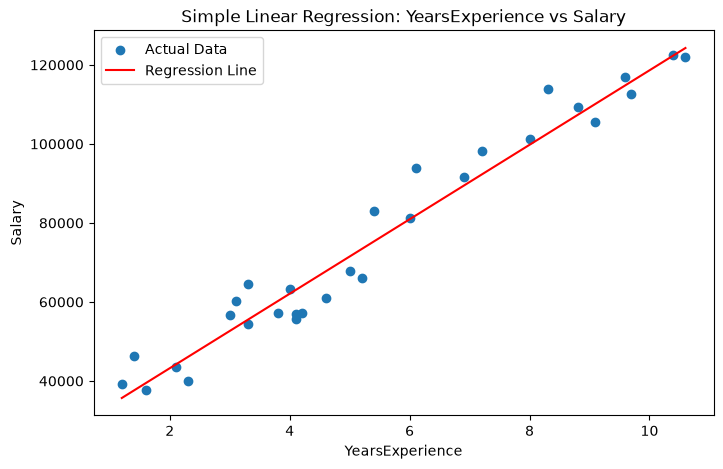

In [28]:
x_line = np.linspace(df[feature_column].min(), df[feature_column].max(), 100)
x_line_df = pd.DataFrame({feature_column: x_line})
y_line = model.predict(x_line_df)

plt.figure(figsize=(8, 5))
plt.scatter(df[feature_column], df[target_column], label="Actual Data")
plt.plot(x_line, y_line, color="red", label="Regression Line")
plt.title(f"Simple Linear Regression: {feature_column} vs {target_column}")
plt.xlabel(feature_column)
plt.ylabel(target_column)
plt.legend()
plt.show()

## 17. Actual vs Predicted Plot

This plot compares the real target values with the model's predicted values. Points close to the red line mean the predictions are close to the actual values.

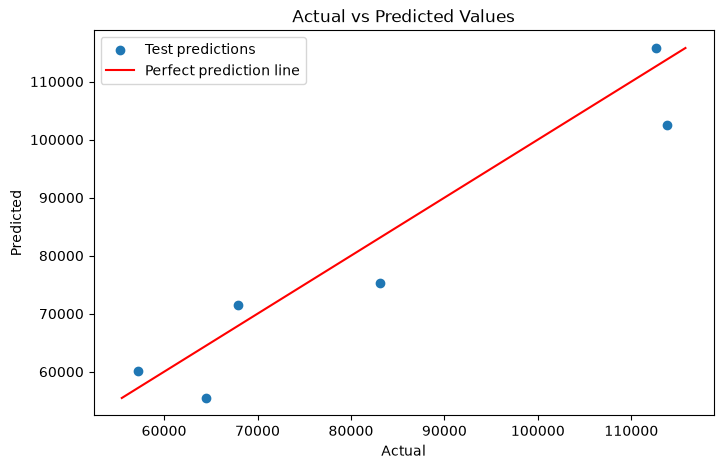

In [29]:
line_start = min(y_test.min(), y_pred.min())
line_end = max(y_test.max(), y_pred.max())

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, label="Test predictions")
plt.plot([line_start, line_end], [line_start, line_end], color="red", label="Perfect prediction line")
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.show()

## 18. Residual Plot

A residual is the difference between the actual value and the predicted value.

`Residual = Actual Value - Predicted Value`

Residuals help us see how far predictions are from actual values.

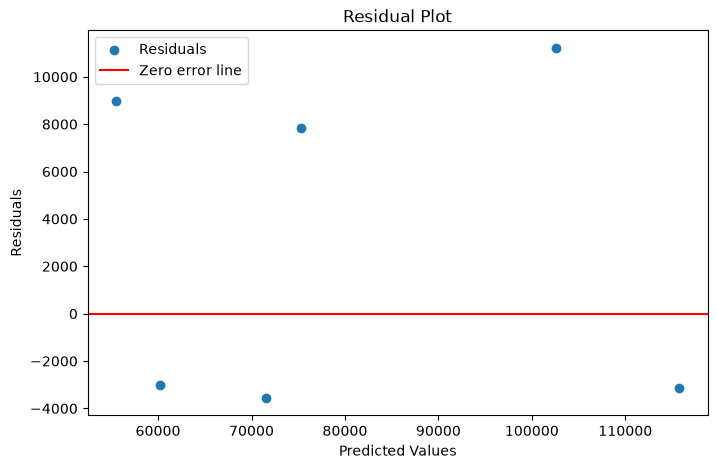

In [30]:
# Residuals show the prediction error for each test row.
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, label="Residuals")
plt.axhline(y=0, color="red", label="Zero error line")
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.legend()
plt.show()

## 19. Predict for a New Value

Now we make a prediction for one new input value. We use a DataFrame with the correct column name so scikit-learn receives the same feature name it saw during training.

To keep the example reasonable, the new value is chosen from the middle of the feature range in the dataset.

In [31]:
# Use the median experience value as a realistic example input.
new_value = round(float(df[feature_column].median()), 2)
new_data = pd.DataFrame({feature_column: [new_value]})
predicted_value = model.predict(new_data)

print(f"For {feature_column} = {new_value}, the predicted {target_column} is {predicted_value[0]:.2f}.")

For YearsExperience = 4.8, the predicted Salary is 69614.52.


## 20. Save the Model

After training a model, we may want to reuse it later without training it again. Saving the model is useful when moving toward deployment or when sharing a trained model with another script or application.

In [32]:
# Save the trained model in the project models folder.
model_path = Path.cwd().parent / "models" / "linear_regression_model.pkl"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: c:\Users\KIIT\Documents\Github projects\ML-Series\linear-regression-practical\models\linear_regression_model.pkl


## 21. Load the Saved Model

Loading the saved model lets us use it again without retraining. This is useful when a trained model is used later in another notebook, script, or application.

In [33]:
loaded_model = joblib.load(model_path)
loaded_prediction = loaded_model.predict(new_data)

print(f"Loaded model prediction for {feature_column} = {new_value}: {loaded_prediction[0]:.2f}")

Loaded model prediction for YearsExperience = 4.8: 69614.52


## 22. Final Summary

In this notebook, we:

- loaded the dataset
- studied the dataset before modeling
- checked columns, data types, missing values, and duplicates
- visualized the relationship between the selected feature and target
- trained a Simple Linear Regression model
- made predictions
- evaluated the model using MAE, MSE, RMSE, and R2 Score
- visualized the regression line, actual vs predicted values, and residuals
- saved and loaded the trained model

The main takeaway is that Machine Learning is not only about calling `model.fit()`. A good workflow starts by understanding the dataset and making clear decisions about the feature, target, and cleaning steps before training the model.